# Spatial distribution of $A_V$: lower branch, upper branch, and both

Same $A_V$ and branch definitions as `color_magnitude_diagram_cleancat.ipynb`:

* $A_V$: each source is slid back along the CT06 MWLoc extinction vector in the F162M vs F162M$-$F210M CMD onto a straight-line fit to the 1 Myr PARSEC isochrone between the 0.1 and 20 $M_\odot$ points (`get_av`).
* Branches (sources with $A_V > 12$): upper branch $F360M-F480M > 0.15 + (1.5/6)(F162M-F210M)$, lower branch otherwise.

Figures produced for each of the three cases (lower only, upper only, lower + upper):

1. mean $A_V$ in spatial bins on the F480M image (bins with fewer than `min_samples` sources masked);
2. number-density (KDE) maps of the sources split into $A_V$ bins. The $A_V$ bin edges are the quartiles of the combined (lower + upper) sample and are shared by all three cases, so a given panel covers the same $A_V$ range in every figure.

In [1]:
from astropy.table import Table
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from astropy.visualization import simple_norm
from dust_extinction.averages import CT06_MWLoc
from scipy.stats import binned_statistic_2d, gaussian_kde

plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 3
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 3

jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')


def get_mag(catalog, ww, filtername='f140m'):
    # Vega magnitudes from the catalog fluxes (same recipe as color_magnitude_diagram_cleancat.ipynb)
    flux = (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag
    return vegamag, vegamag_err


image_filenames = {
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits",
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
}
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
catalog = catalog[catalog['nmatch_bands'] > 3]

headers = {filt: fits.getheader(fn, ext=('SCI', 1)) for filt, fn in image_filenames.items()}
f162 = get_mag(catalog, WCS(headers['f162m']), 'f162m')[0].to_value(u.mag)
f210 = get_mag(catalog, WCS(headers['f210m']), 'f210m')[0].to_value(u.mag)
f335 = get_mag(catalog, WCS(headers['f335m']), 'f335m')[0].to_value(u.mag)
f360 = get_mag(catalog, WCS(headers['f360m']), 'f360m')[0].to_value(u.mag)
f410 = get_mag(catalog, WCS(headers['f410m']), 'f410m')[0].to_value(u.mag)
f480 = get_mag(catalog, WCS(headers['f480m']), 'f480m')[0].to_value(u.mag)
print('N sources (nmatch_bands > 3):', len(catalog))

N sources (nmatch_bands > 3): 15004


Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T14:19:01.510' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.130' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220310 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512065.053 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '

In [2]:
# --- A_V from the F162M vs F162M-F210M CMD (same as av_estimate in the CMD notebook) ---
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0 = parsec_av0[parsec_av0['col4'] < 300]
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
F162Mmag_av0 = parsec_av0['col40'] + 5*np.log10(5400) - 5
F210Mmag_av0 = parsec_av0['col42'] + 5*np.log10(5400) - 5

age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx] - 0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx] - 20))


def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    m_iso, b_iso = isochrone_line_params
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # intersection of the extinction vector through (color, mag) with the isochrone line
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    av = (mag - y_int) / e_mag1
    av[av < 0] = 0
    return av


isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isochrone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isochrone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start

av_estimate = get_av(f162 - f210, f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',),
                     isochrone_line_params=(color_slope, color_intercept))

lower branch           N =  2260   median A_V = 32.3
upper branch           N =  1106   median A_V = 29.8
lower + upper branch   N =  3366   median A_V = 31.8


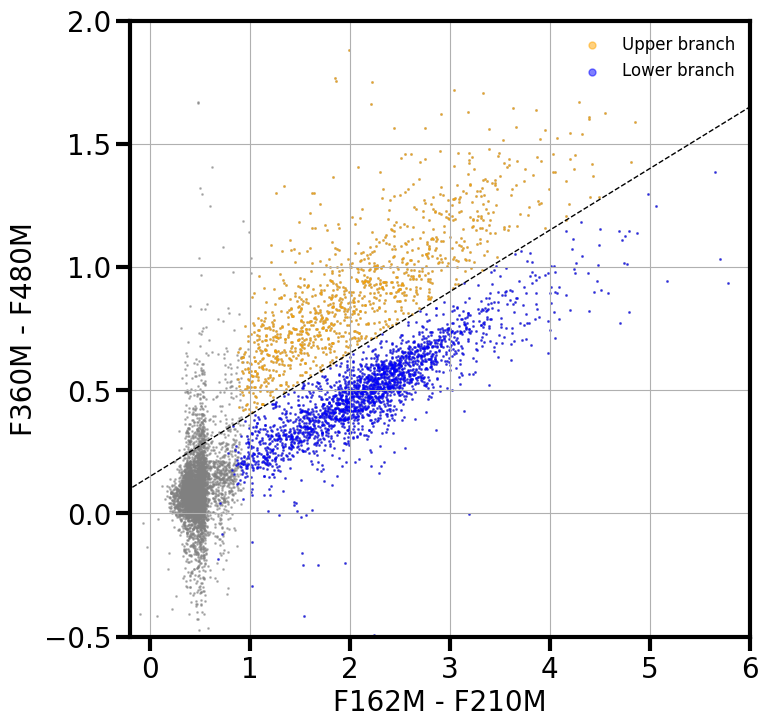

In [3]:
# --- lower / upper branch selection (same cut as the CMD notebook), as boolean masks ---
branch_line = 0.15 + (1.5/6) * (f162 - f210)
upper_mask = (f360 - f480 > branch_line) & (av_estimate > 12)
lower_mask = (f360 - f480 <= branch_line) & (av_estimate > 12)
all_mask = upper_mask | lower_mask

cases = [
    ('lower branch', 'lower', lower_mask, 'blue'),
    ('upper branch', 'upper', upper_mask, 'orange'),
    ('lower + upper branch', 'all', all_mask, 'k'),
]
for label, tag, m, color in cases:
    print(f'{label:22s} N = {m.sum():5d}   median A_V = {np.median(av_estimate[m]):.1f}')

# quick check of the selection in the color-color diagram
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(f162 - f210, f360 - f480, s=1, c='gray', alpha=0.5)
ax.scatter((f162 - f210)[upper_mask], (f360 - f480)[upper_mask], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter((f162 - f210)[lower_mask], (f360 - f480)[lower_mask], s=1, c='blue', alpha=0.5, label='Lower branch')
xarr = np.linspace(-0.3, 6, 10)
ax.plot(xarr, 0.15 + (1.5/6)*xarr, 'k--', lw=1)
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F360M - F480M')
ax.set_xlim(-0.2, 6)
ax.set_ylim(-0.5, 2)
ax.grid()
ax.legend(markerscale=5, fontsize=12, frameon=False)
plt.show()

In [4]:
# --- F480M image, WCS, and source pixel positions ---
wcs_f480m = WCS(headers['f480m'])
f480m_data = fits.getdata(image_filenames['f480m'], ext=('SCI', 1))
norm_f480m = simple_norm(f480m_data, stretch='log', percent=99.)

skycoord_ref = catalog['skycoord_ref']
pixcoord_ref = wcs_f480m.all_world2pix(skycoord_ref.ra.deg, skycoord_ref.dec.deg, 0)


def format_wcs_axes(ax):
    # tick formatting only -- axis labels are set per figure
    ra = ax.coords['ra']
    dec = ax.coords['dec']
    ra.set_major_formatter('hh:mm:ss.ss')
    dec.set_major_formatter('dd:mm:ss.ss')
    ra.set_ticklabel(rotation=90, pad=30)
    ra.set_ticks_position('l')
    ra.set_ticklabel_position('l')
    ra.set_axislabel('')
    dec.set_ticks_position('b')
    dec.set_ticklabel_position('b')
    dec.set_axislabel('')

Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## 1. Mean $A_V$ in spatial bins

Sources are binned on the F480M pixel grid (`bin_size_px` pixels per bin) and the mean $A_V$ is shown for bins with at least `min_samples` sources. The bin grid and color scale are identical for the three figures.

lower branch           bins with N >= 3: 245


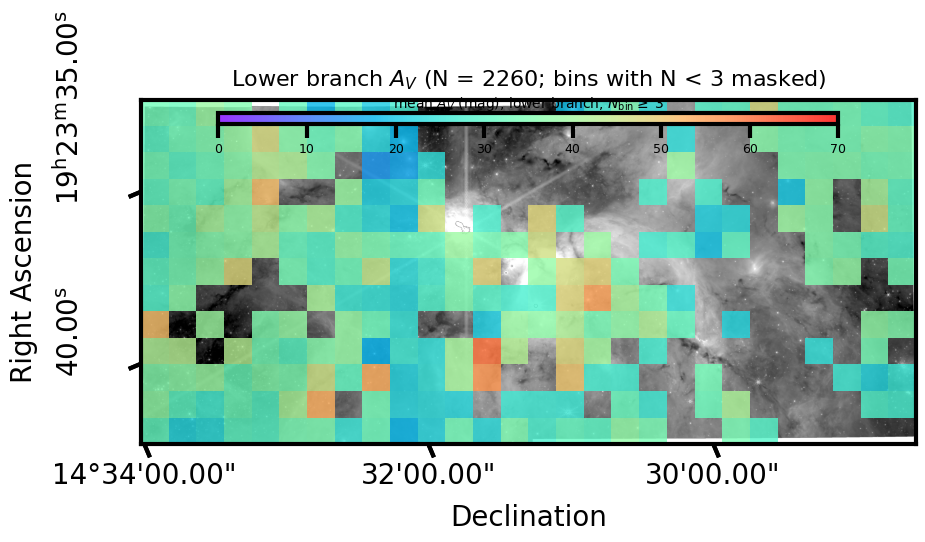

upper branch           bins with N >= 3: 158


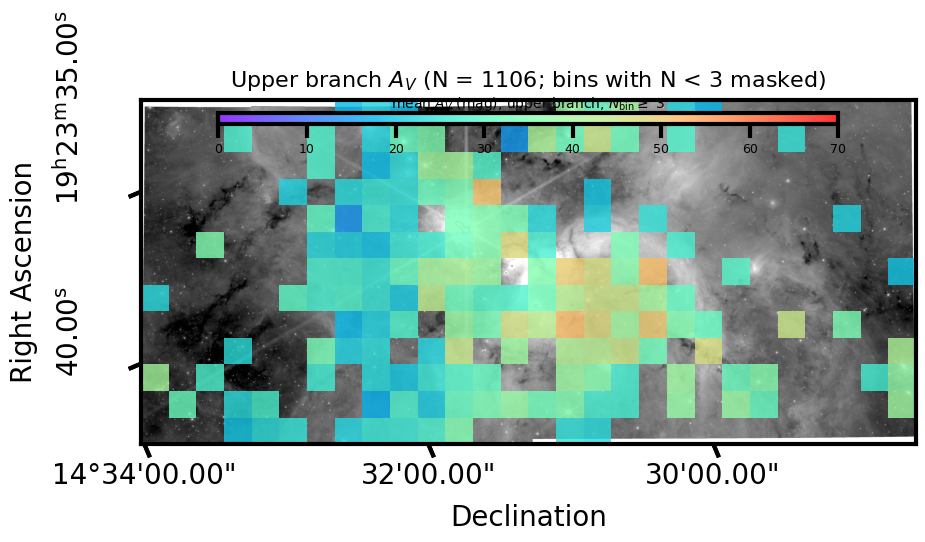

lower + upper branch   bins with N >= 3: 316


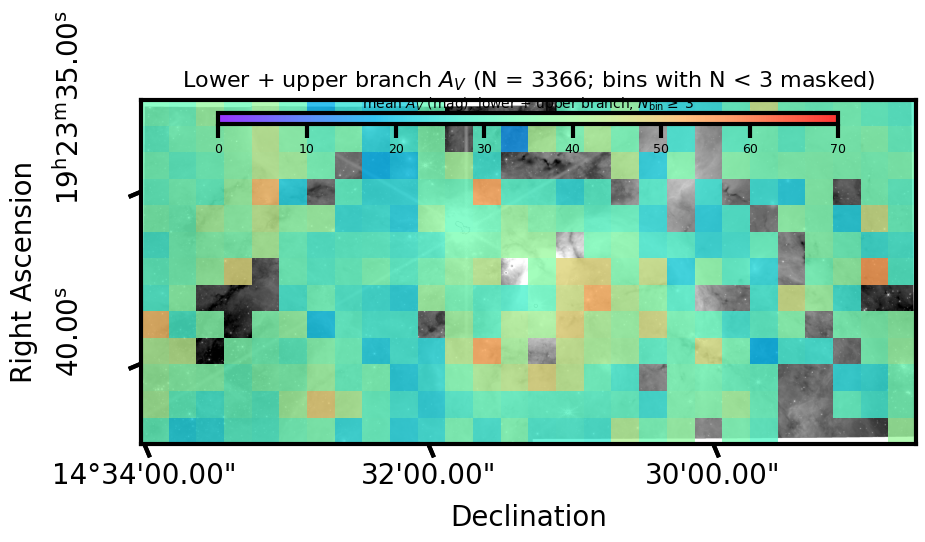

In [5]:
min_samples = 3    # minimum sources per spatial bin
bin_size_px = 200  # spatial bin size in F480M pixels
av_vmin, av_vmax = 0, 70

nbins_x = max(1, int(round(f480m_data.shape[1] / bin_size_px)))
nbins_y = max(1, int(round(f480m_data.shape[0] / bin_size_px)))
xedges = np.linspace(0, f480m_data.shape[1], nbins_x + 1)
yedges = np.linspace(0, f480m_data.shape[0], nbins_y + 1)

av_mean_maps = {}
for label, tag, m, color in cases:
    x, y, av = pixcoord_ref[0][m], pixcoord_ref[1][m], av_estimate[m]
    av_mean, _, _, _ = binned_statistic_2d(x, y, av, statistic='mean', bins=[xedges, yedges])
    av_counts, _, _, _ = binned_statistic_2d(x, y, av, statistic='count', bins=[xedges, yedges])
    av_mean_reliable = np.where(av_counts >= min_samples, av_mean, np.nan)
    av_mean_maps[tag] = av_mean_reliable
    print(f'{label:22s} bins with N >= {min_samples}: {np.isfinite(av_mean_reliable).sum()}')

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection=wcs_f480m)
    ax.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
    im = ax.imshow(
        av_mean_reliable.T,
        origin='lower',
        cmap='rainbow',
        alpha=0.8,
        vmin=av_vmin, vmax=av_vmax,
        extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
        interpolation='nearest',
    )
    cax = ax.inset_axes([0.1, 0.93, 0.8, 0.03], transform=ax.transAxes)
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(r'mean $A_V$ (mag), ' + label + r', $N_{\rm bin} \geq$ ' + str(min_samples), fontsize=10)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.tick_params(labelsize=9)

    format_wcs_axes(ax)
    ax.set_xlabel('Declination')
    ax.set_ylabel('Right Ascension')
    ax.set_title(f'{label.capitalize()} $A_V$ (N = {m.sum()}; bins with N < {min_samples} masked)', fontsize=16)
    plt.savefig(f'av_mean_map_{tag}_branch_cfit003.png', bbox_inches='tight')
    plt.show()

## 2. Number density in bins of $A_V$

The $A_V$ bin edges are the quartiles of the combined lower + upper sample, applied to all three cases. Each panel is a Gaussian KDE of the source positions scaled by the number of sources in that $A_V$ bin (sources per unit KDE area, as in the CMD notebook). Within a figure the four panels share one color scale; set `share_density_scale = True` to use one color scale across all three figures.

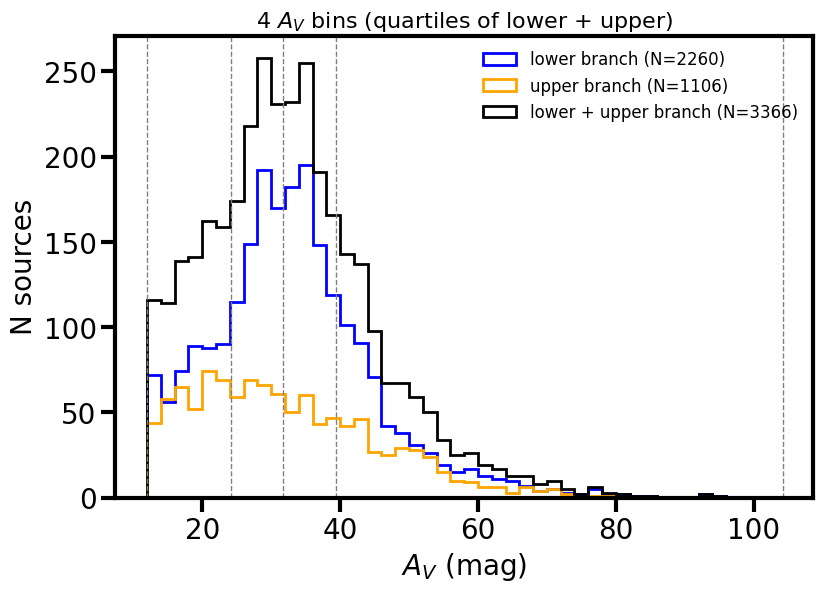

lower branch           N per A_V bin: [np.int64(475), np.int64(602), np.int64(637), np.int64(546)]
upper branch           N per A_V bin: [np.int64(367), np.int64(239), np.int64(204), np.int64(296)]
lower + upper branch   N per A_V bin: [np.int64(842), np.int64(841), np.int64(841), np.int64(842)]


In [6]:
n_av_bins = 4
av_bin_edges = np.percentile(av_estimate[all_mask], np.linspace(0, 100, n_av_bins + 1))
av_bin_edges[-1] += 1e-6  # make the top edge inclusive
av_bin_labels = [f'{lo:.1f} $\\leq A_V <$ {hi:.1f}' for lo, hi in zip(av_bin_edges[:-1], av_bin_edges[1:])]

fig, ax = plt.subplots(figsize=(9, 6))
hist_bins = np.arange(12, 106, 2)
for label, tag, m, color in cases:
    ax.hist(av_estimate[m], bins=hist_bins, histtype='step', lw=2, color=color, label=f'{label} (N={m.sum()})')
for edge in av_bin_edges:
    ax.axvline(edge, color='gray', ls='--', lw=1)
ax.set_xlabel(r'$A_V$ (mag)')
ax.set_ylabel('N sources')
ax.set_title(f'{n_av_bins} $A_V$ bins (quartiles of lower + upper)', fontsize=16)
ax.legend(fontsize=12, frameon=False)
plt.savefig('av_bin_histogram_branches_cfit003.png', bbox_inches='tight')
plt.show()

for label, tag, m, color in cases:
    counts = [(m & (av_estimate >= lo) & (av_estimate < hi)).sum()
              for lo, hi in zip(av_bin_edges[:-1], av_bin_edges[1:])]
    print(f'{label:22s} N per A_V bin: {counts}')

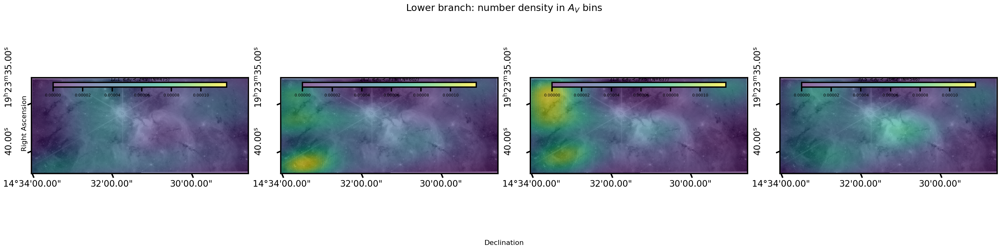

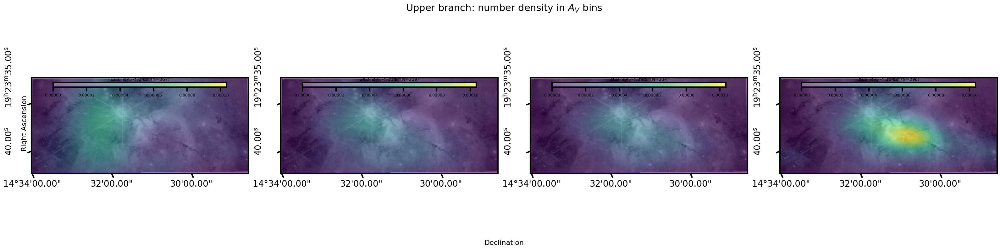

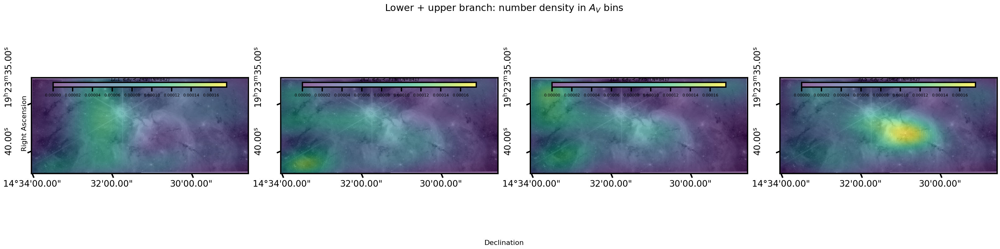

In [7]:
share_density_scale = False  # True: one color scale across the three figures

xgrid = np.linspace(0, f480m_data.shape[1], 100)
ygrid = np.linspace(0, f480m_data.shape[0], 100)
Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)
grid_points = np.vstack([Xgrid.ravel(), Ygrid.ravel()])

density_maps = {}
bin_masks = {}
for label, tag, m, color in cases:
    density_maps[tag], bin_masks[tag] = [], []
    for lo, hi in zip(av_bin_edges[:-1], av_bin_edges[1:]):
        mb = m & (av_estimate >= lo) & (av_estimate < hi)
        bin_masks[tag].append(mb)
        if mb.sum() < 3:
            # too few sources for a 2D KDE
            density_maps[tag].append(np.full(Xgrid.shape, np.nan))
            continue
        kde = gaussian_kde(np.vstack([pixcoord_ref[0][mb], pixcoord_ref[1][mb]]))
        density_maps[tag].append(kde(grid_points).reshape(Xgrid.shape) * mb.sum())

vmax_global = np.nanmax([np.nanmax(d) for maps in density_maps.values() for d in maps])

for label, tag, m, color in cases:
    vmax_density = vmax_global if share_density_scale else np.nanmax([np.nanmax(d) for d in density_maps[tag]])
    fig, axes = plt.subplots(1, n_av_bins, figsize=(8 * n_av_bins, 8), subplot_kw={'projection': wcs_f480m})
    for axi, bin_label, mb, density in zip(axes, av_bin_labels, bin_masks[tag], density_maps[tag]):
        axi.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
        im = axi.imshow(
            density,
            origin='lower',
            cmap='viridis',
            alpha=0.6,
            vmin=0, vmax=vmax_density,
            extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()],
            interpolation='nearest',
        )
        cax = axi.inset_axes([0.1, 0.9, 0.8, 0.05], transform=axi.transAxes)
        cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
        cbar.ax.xaxis.set_label_position('top')
        cbar.set_label(f'{bin_label}  (N={mb.sum()})', fontsize=10)
        cbar.ax.tick_params(labelsize=9)
        format_wcs_axes(axi)

    fig.suptitle(f'{label.capitalize()}: number density in $A_V$ bins', fontsize=22)
    fig.supxlabel('Declination', fontsize=16)
    fig.supylabel('Right Ascension', fontsize=16)
    fig.subplots_adjust(left=0.03, right=0.99, bottom=0.1, top=0.88, wspace=0.15)
    plt.savefig(f'av_bin_density_maps_{tag}_branch_cfit003.png', bbox_inches='tight')
    plt.show()

## 3. Maximum $A_V$ in spatial bins

Same spatial bins (`xedges`, `yedges`), `min_samples` threshold and color scale as Section 1, with the maximum $A_V$ per bin instead of the mean (the lower-branch version of this map is in the CMD notebook, `av_max_lower_branch_spatial_map_cfit003.png`). Bins with fewer than `min_samples` sources are masked.

lower branch           bins with N >= 3: 245   median of bin max A_V = 46.7


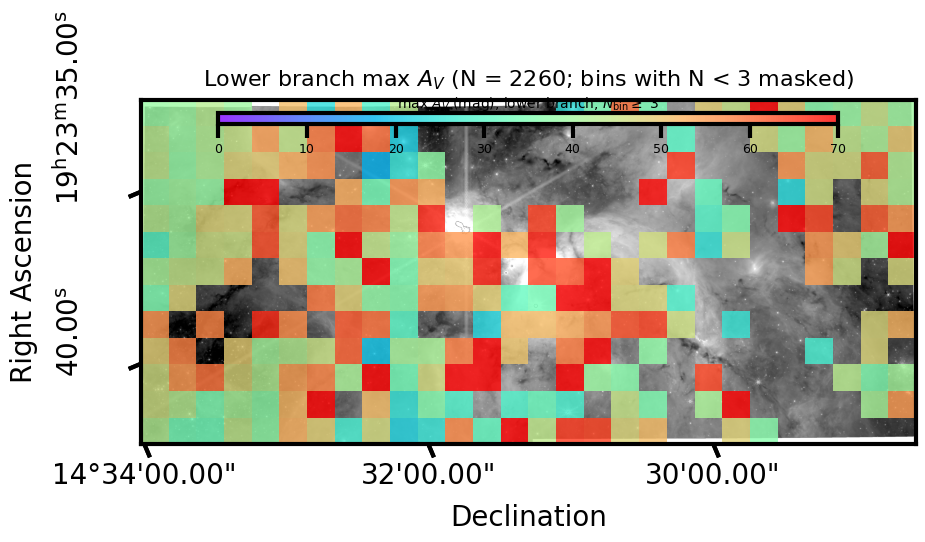

upper branch           bins with N >= 3: 158   median of bin max A_V = 44.0


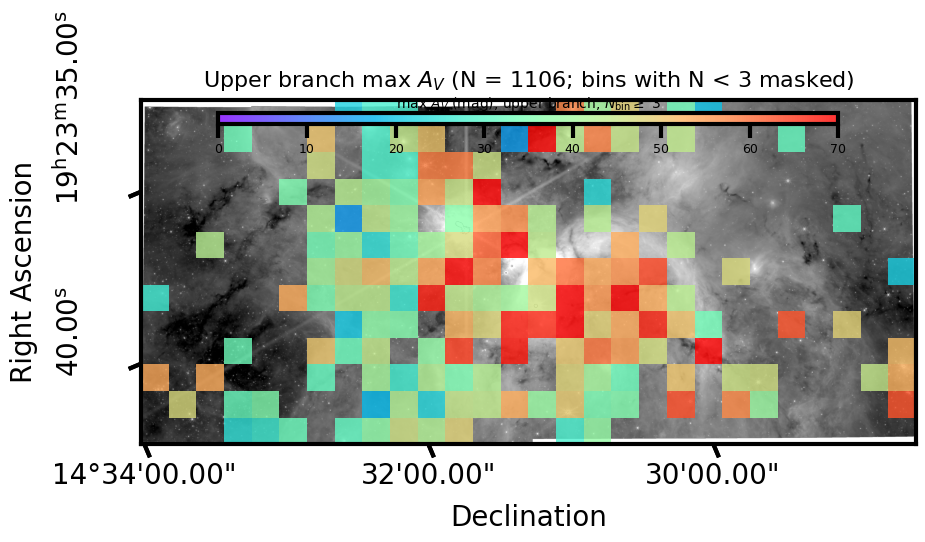

lower + upper branch   bins with N >= 3: 316   median of bin max A_V = 47.9


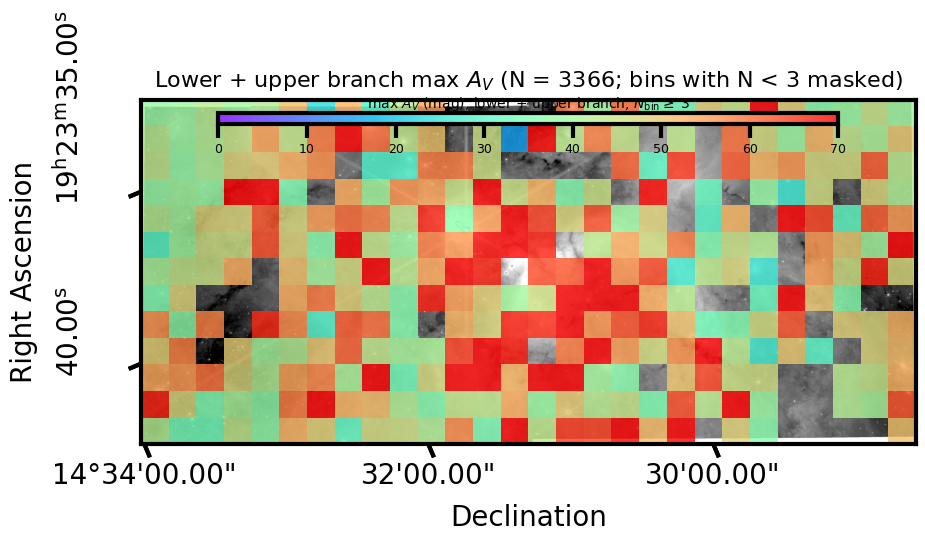

In [8]:
av_max_maps = {}
for label, tag, m, color in cases:
    x, y, av = pixcoord_ref[0][m], pixcoord_ref[1][m], av_estimate[m]
    av_max, _, _, _ = binned_statistic_2d(x, y, av, statistic='max', bins=[xedges, yedges])
    av_counts, _, _, _ = binned_statistic_2d(x, y, av, statistic='count', bins=[xedges, yedges])
    av_max_reliable = np.where(av_counts >= min_samples, av_max, np.nan)
    av_max_maps[tag] = av_max_reliable
    print(f'{label:22s} bins with N >= {min_samples}: {np.isfinite(av_max_reliable).sum()}   '
          f'median of bin max A_V = {np.nanmedian(av_max_reliable):.1f}')

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection=wcs_f480m)
    ax.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
    im = ax.imshow(
        av_max_reliable.T,
        origin='lower',
        cmap='rainbow',
        alpha=0.8,
        vmin=av_vmin, vmax=av_vmax,
        extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
        interpolation='nearest',
    )
    cax = ax.inset_axes([0.1, 0.93, 0.8, 0.03], transform=ax.transAxes)
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(r'max $A_V$ (mag), ' + label + r', $N_{\rm bin} \geq$ ' + str(min_samples), fontsize=10)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.tick_params(labelsize=9)

    format_wcs_axes(ax)
    ax.set_xlabel('Declination')
    ax.set_ylabel('Right Ascension')
    ax.set_title(f'{label.capitalize()} max $A_V$ (N = {m.sum()}; bins with N < {min_samples} masked)', fontsize=16)
    plt.savefig(f'av_max_map_{tag}_branch_cfit003.png', bbox_inches='tight')
    plt.show()

## 4. Maximum $A_V$ maps with very red sources and dereddened F335M$-$F360M overlaid

Populations and colors as in `color_magnitude_diagram_cleancat.ipynb`:

* **Very red sources**: F162M or F210M missing and F410M$-$F480M $> 0.5$ (`missing_nir_idx_red` in the CMD notebook). They have no CMD $A_V$, so they are not part of any branch and appear in every figure.
* **Dereddened color**: $(F335M-F360M)_0 = (F335M-F360M)_{\rm obs} - A_V\,(A_{3.35}-A_{3.60})/A_V$ with the CT06 MWLoc law. The CMD notebook uses `av_dered` (F162M CMD $A_V$, F140M CMD as fallback). Every branch source has an F162M CMD $A_V > 12$, so `av_dered` equals `av_estimate` for them. Colors use the `rainbow` map over the 2nd–98th percentile of the lower + upper sample, with sources drawn in order of increasing color so the reddest are on top, as in the CMD notebook (`map_dereddened_335m360_cfit003.png`).

Each figure has the same max $A_V$ map as Section 3 in both panels. Top: very red sources. Bottom: the branch sources of that case color-coded by $(F335M-F360M)_0$. Two `rainbow` scales on top of each other would be hard to read, so the max $A_V$ map in these figures is drawn opaque in `av_overlay_cmap` without the F480M image underneath (same bins, `vmin`/`vmax` and masking as Section 3; masked bins are white).

In [9]:
# --- very red sources (same cut as missing_nir_idx_red in the CMD notebook) ---
missing_nir = ~np.isfinite(f162) | ~np.isfinite(f210)
with np.errstate(invalid='ignore'):
    veryred_mask = missing_nir & (f410 - f480 > 0.5)
print('very red sources: N =', veryred_mask.sum())

# --- dereddened F335M-F360M (same CT06 MWLoc law and E/A_V as the CMD notebook) ---
ext_law = CT06_MWLoc()
A_per_av = {f: float(ext_law(1/(int(f[1:-1])/100*u.um))) for f in ['f335m', 'f360m']}
E_335_360_per_av = A_per_av['f335m'] - A_per_av['f360m']
print(f'per unit A_V: E(F335M-F360M) = {E_335_360_per_av:.4f}')
color_335_360_dered = (f335 - f360) - av_estimate * E_335_360_per_av

has_dered = np.isfinite(color_335_360_dered)
cvmin, cvmax = np.percentile(color_335_360_dered[has_dered & all_mask], [2, 98])
print(f'color scale: (F335M-F360M)_0 from {cvmin:.2f} to {cvmax:.2f} (2nd-98th pct of lower + upper branch)')
color_norm = mpl.colors.Normalize(vmin=cvmin, vmax=cvmax)
for label, tag, m, color in cases:
    sel = m & has_dered
    print(f'{label:22s} N with (F335M-F360M)_0 = {sel.sum():5d}   median = {np.median(color_335_360_dered[sel]):.2f}')

very red sources: N = 893
per unit A_V: E(F335M-F360M) = 0.0042
color scale: (F335M-F360M)_0 from 0.02 to 0.71 (2nd-98th pct of lower + upper branch)
lower branch           N with (F335M-F360M)_0 =  2236   median = 0.20
upper branch           N with (F335M-F360M)_0 =  1091   median = 0.28
lower + upper branch   N with (F335M-F360M)_0 =  3327   median = 0.22


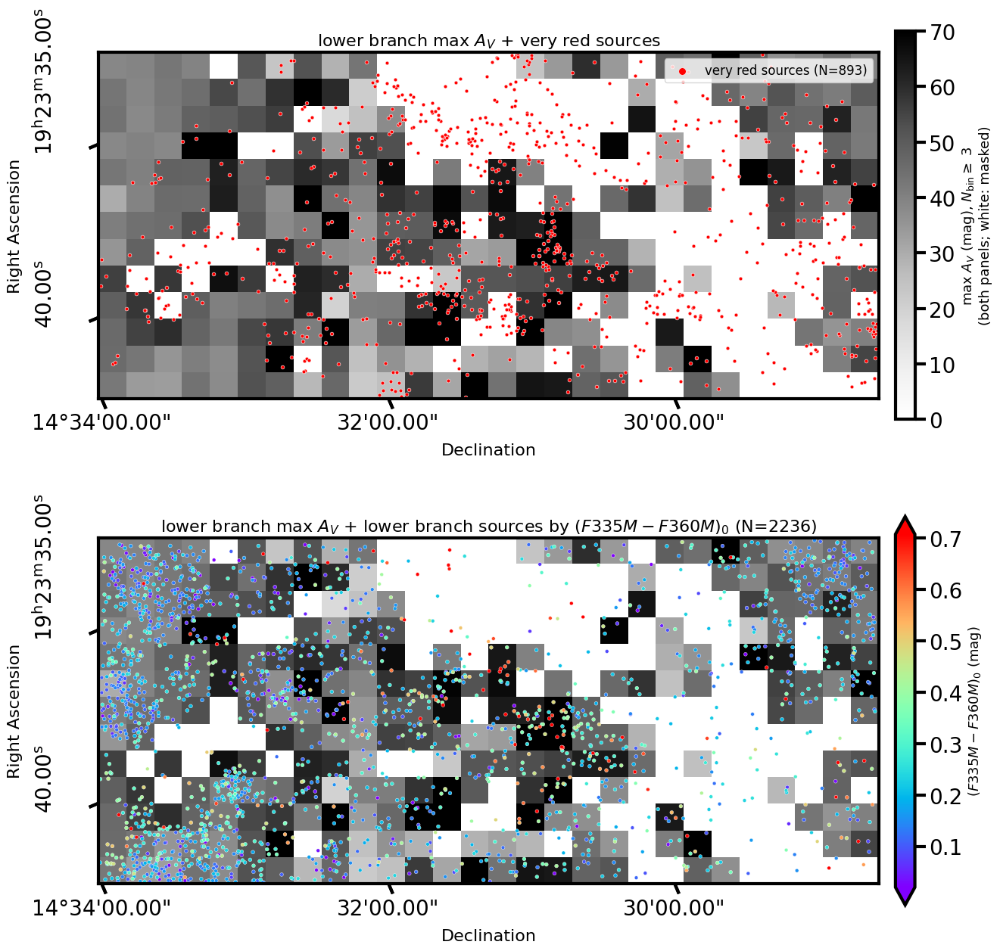

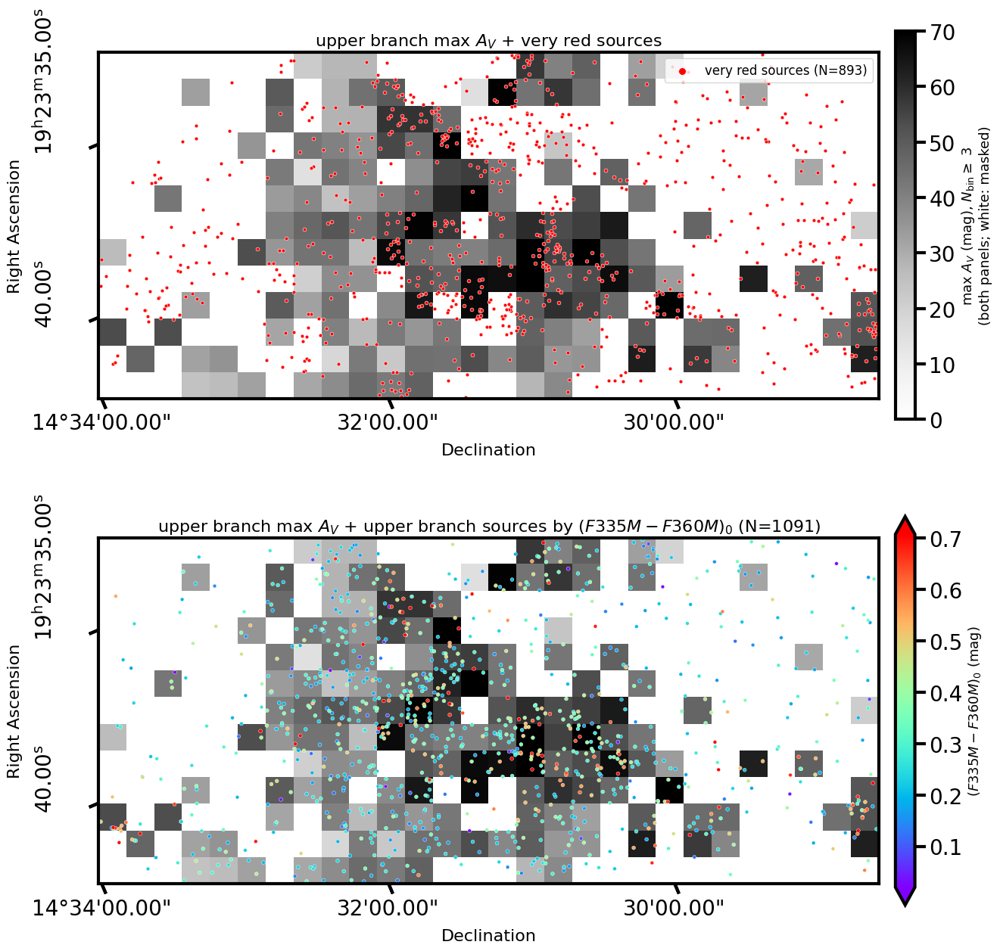

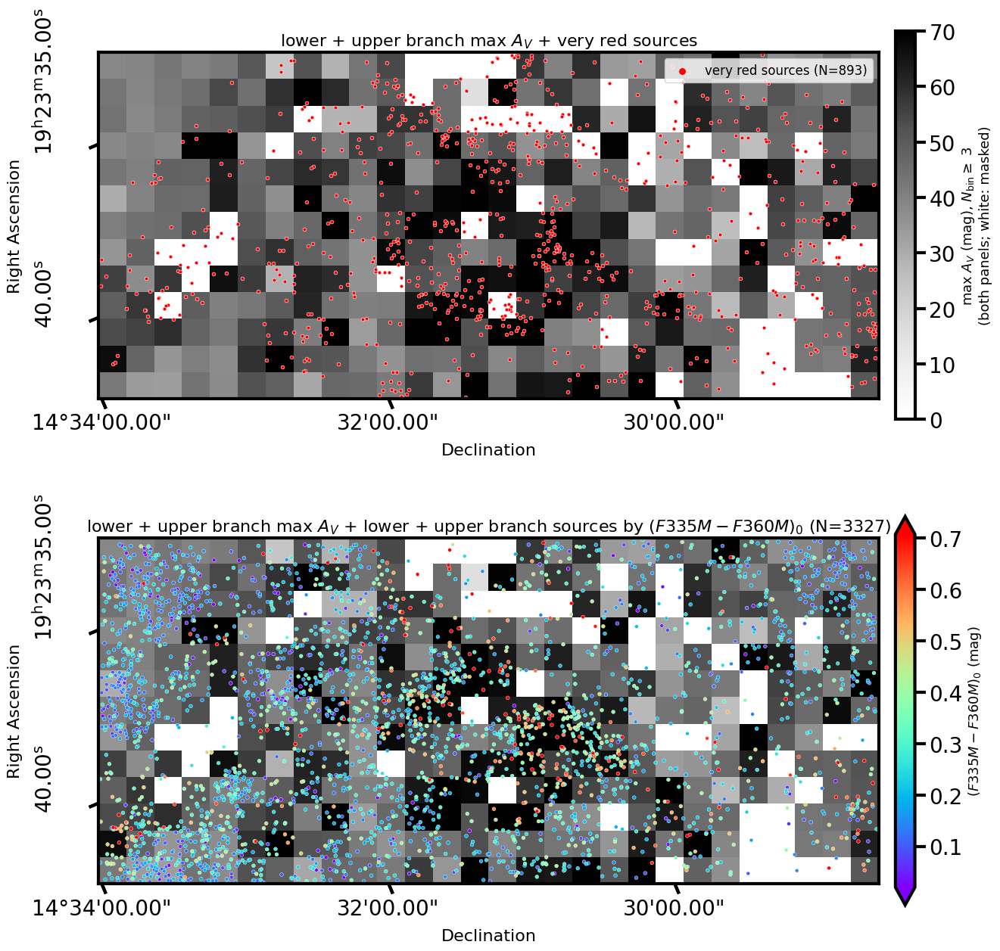

In [10]:
av_overlay_cmap = 'Greys'  # colormap of the max A_V map in the overlay figures (opaque, no F480M underlay)

for label, tag, m, color in cases:
    fig, axes = plt.subplots(2, 1, figsize=(14, 15), subplot_kw={'projection': wcs_f480m})
    for axi in axes:
        im_av = axi.imshow(
            av_max_maps[tag].T,
            origin='lower',
            cmap=av_overlay_cmap,
            vmin=av_vmin, vmax=av_vmax,
            extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
            interpolation='nearest',
        )
        axi.set_xlim(0, f480m_data.shape[1])
        axi.set_ylim(0, f480m_data.shape[0])
        format_wcs_axes(axi)

    # (i) very red sources
    axes[0].scatter(pixcoord_ref[0][veryred_mask], pixcoord_ref[1][veryred_mask], s=12, c='r',
                    edgecolors='w', linewidths=0.4, label=f'very red sources (N={veryred_mask.sum()})')
    axes[0].legend(markerscale=2, fontsize=12, loc='upper right')
    axes[0].set_title(f'{label} max $A_V$ + very red sources', fontsize=16)

    # (ii) branch sources color coded by the dereddened F335M-F360M color, reddest on top
    sel = m & has_dered
    order = np.where(sel)[0][np.argsort(color_335_360_dered[sel])]
    im_c = axes[1].scatter(pixcoord_ref[0][order], pixcoord_ref[1][order], c=color_335_360_dered[order], s=12,
                           cmap='rainbow', norm=color_norm, edgecolors='w', linewidths=0.3)
    axes[1].set_title(f'{label} max $A_V$ + {label} sources by $(F335M-F360M)_0$ (N={sel.sum()})', fontsize=16)

    for axi in axes:
        axi.set_xlabel('Declination', fontsize=16)
        axi.set_ylabel('Right Ascension', fontsize=16)
    # one vertical colorbar per panel with the same size, so the two panels stay aligned;
    # the max A_V scale (top) applies to both panels
    cbar_av = fig.colorbar(im_av, ax=axes[0], orientation='vertical', fraction=0.03, pad=0.02)
    cbar_av.set_label(r'max $A_V$ (mag), $N_{\rm bin} \geq$ ' + str(min_samples) + '\n(both panels; white: masked)', fontsize=13)
    cbar_c = fig.colorbar(im_c, ax=axes[1], orientation='vertical', fraction=0.03, pad=0.02, extend='both')
    cbar_c.set_label(r'$(F335M - F360M)_0$ (mag)', fontsize=13)
    fig.subplots_adjust(hspace=0.25)
    plt.savefig(f'av_max_map_{tag}_branch_veryred_dered335m360_cfit003.png', bbox_inches='tight', dpi=150)
    plt.show()


## 5. Bin $A_V$ vs. the sources sitting in each bin

Each source is assigned the mean $A_V$ (Section 1) and max $A_V$ (Section 3) of the spatial bin it falls in, separately for the lower-branch, upper-branch and lower + upper maps. Sources in masked bins ($N_{\rm bin} <$ `min_samples`) get no bin $A_V$ and are left out.

**5a.** Bin $A_V$ vs. $(F335M-F360M)_0$ of the branch sources in that bin. Gray points are individual sources. The black line and band are the median and 16th–84th percentile of the color in `corr_av_bin_width`-mag steps of bin $A_V$ (steps with fewer than `corr_min_per_step` sources are dropped). The Spearman rank coefficient is printed in each panel. The color is dereddened with each source's own $A_V$, $(F335M-F360M)_0 = (F335M-F360M)_{\rm obs} - 0.0042\,A_V$, and a source's own $A_V$ contributes to its bin's mean and max. Part of any trend can therefore come from the dereddening itself: 0.0042 mag per mag of $A_V$, i.e. about 0.2 mag across $A_V = 20$–70. The dashed red line shows this slope (anchored at the median point) for reference.

**5b.** Histograms of bin $A_V$, counted over the very red sources in each bin (each very red source adds its bin's $A_V$ once). For comparison, the gray step histogram is the same quantity counted over the branch sources of that map, scaled to the same total, so the two shapes can be compared directly. The number of very red sources in masked bins (no bin $A_V$) is given in each panel.

In [11]:
from scipy.stats import spearmanr

# spatial bin index of every source on the Section 1/3 grid
ix_src = np.searchsorted(xedges, pixcoord_ref[0], side='right') - 1
iy_src = np.searchsorted(yedges, pixcoord_ref[1], side='right') - 1
in_grid = (ix_src >= 0) & (ix_src < len(xedges) - 1) & (iy_src >= 0) & (iy_src < len(yedges) - 1)
ix_src, iy_src = np.clip(ix_src, 0, len(xedges) - 2), np.clip(iy_src, 0, len(yedges) - 2)


def bin_value_at_sources(bin_map):
    # value of the source's spatial bin (NaN for masked bins or sources outside the grid)
    return np.where(in_grid, bin_map[ix_src, iy_src], np.nan)


bin_av_at_src = {stat: {tag: bin_value_at_sources(maps[tag]) for _, tag, _, _ in cases}
                 for stat, maps in [('mean', av_mean_maps), ('max', av_max_maps)]}
print('sources outside the bin grid:', (~in_grid).sum())

sources outside the bin grid: 166


mean lower branch           N =  2093  Spearman rho = +0.238  p = 2.38e-28
mean upper branch           N =   904  Spearman rho = +0.407  p = 1.84e-37
mean lower + upper branch   N =  3259  Spearman rho = +0.247  p = 1.12e-46
max  lower branch           N =  2093  Spearman rho = +0.274  p = 1.94e-37
max  upper branch           N =   904  Spearman rho = +0.354  p = 4.50e-28
max  lower + upper branch   N =  3259  Spearman rho = +0.309  p = 4.34e-73


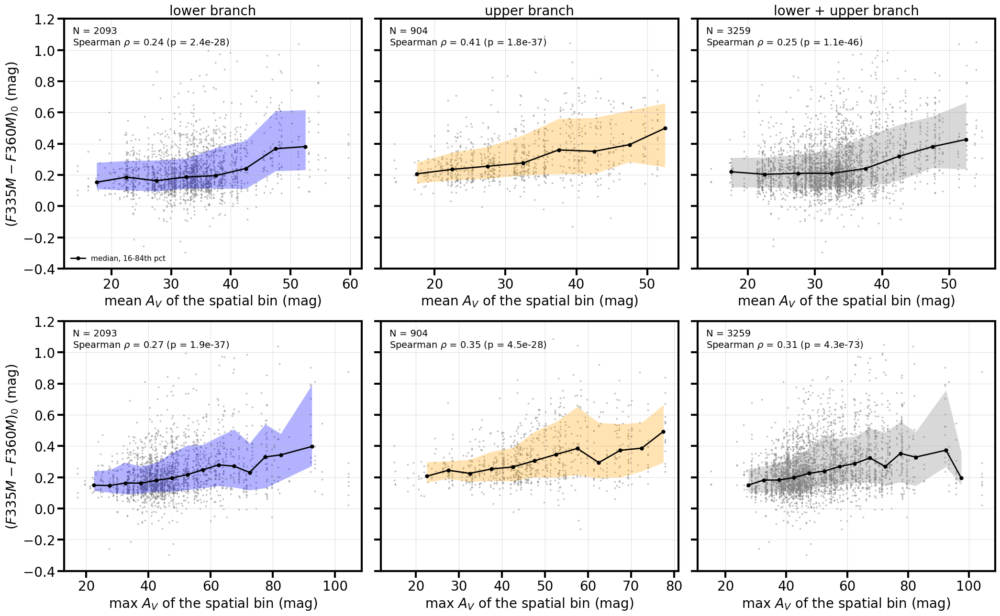

In [12]:
# --- 5a: bin A_V (mean / max) vs dereddened F335M-F360M of the sources in the bin ---
corr_av_bin_width = 5   # mag, step in bin A_V for the running median
corr_min_per_step = 10  # minimum sources per step

fig, axes = plt.subplots(2, len(cases), figsize=(7 * len(cases), 13), sharey=True)
for row, stat in enumerate(['mean', 'max']):
    for col, (label, tag, m, color) in enumerate(cases):
        ax = axes[row, col]
        xb = bin_av_at_src[stat][tag]
        sel = m & has_dered & np.isfinite(xb)
        x, y = xb[sel], color_335_360_dered[sel]
        ax.scatter(x, y, s=3, c='gray', alpha=0.4, rasterized=True)

        steps = np.arange(np.floor(x.min() / corr_av_bin_width) * corr_av_bin_width,
                          x.max() + corr_av_bin_width, corr_av_bin_width)
        cen, med, lo, hi = [], [], [], []
        for a, b in zip(steps[:-1], steps[1:]):
            yy = y[(x >= a) & (x < b)]
            if yy.size >= corr_min_per_step:
                cen.append(0.5 * (a + b))
                med.append(np.median(yy))
                lo.append(np.percentile(yy, 16))
                hi.append(np.percentile(yy, 84))
        cen, med = np.array(cen), np.array(med)
        ax.fill_between(cen, lo, hi, color=color if color != 'k' else 'gray', alpha=0.3, lw=0)
        ax.plot(cen, med, 'k-o', lw=2, ms=5, label='median, 16-84th pct')

        # slope from the dereddening alone, anchored at the median point of the sample
        x0, y0 = np.median(x), np.median(y)
        xx = np.array([x.min(), x.max()])
        #ax.plot(xx, y0 - E_335_360_per_av * (xx - x0), 'r--', lw=1.5,
        #        label=rf'slope $-E/A_V$ = $-${E_335_360_per_av:.4f}')

        rho, p = spearmanr(x, y)
        ax.text(0.03, 0.97, f'N = {sel.sum()}\nSpearman $\\rho$ = {rho:.2f} (p = {p:.1e})',
                transform=ax.transAxes, ha='left', va='top', fontsize=14)
        print(f'{stat:4s} {label:22s} N = {sel.sum():5d}  Spearman rho = {rho:+.3f}  p = {p:.2e}')

        ax.set_xlabel(f'{stat} $A_V$ of the spatial bin (mag)')
        if col == 0:
            ax.set_ylabel(r'$(F335M - F360M)_0$ (mag)')
        if row == 0:
            ax.set_title(label)
        ax.set_ylim(-0.4, 1.2)
        ax.grid(alpha=0.4)
axes[0, 0].legend(fontsize=11, frameon=False, loc='lower left')
plt.tight_layout()
plt.savefig('bin_av_vs_dered335m360_branches_cfit003.png', bbox_inches='tight', dpi=150)
plt.show()

mean lower branch           very red: N =  510 (in masked bins:  383), median bin A_V = 34.8; branch sources median bin A_V = 33.4
mean upper branch           very red: N =  467 (in masked bins:  426), median bin A_V = 37.7; branch sources median bin A_V = 32.2
mean lower + upper branch   very red: N =  754 (in masked bins:  139), median bin A_V = 34.1; branch sources median bin A_V = 32.7
max  lower branch           very red: N =  510 (in masked bins:  383), median bin A_V = 50.2; branch sources median bin A_V = 44.6
max  upper branch           very red: N =  467 (in masked bins:  426), median bin A_V = 50.4; branch sources median bin A_V = 45.6
max  lower + upper branch   very red: N =  754 (in masked bins:  139), median bin A_V = 52.4; branch sources median bin A_V = 47.1


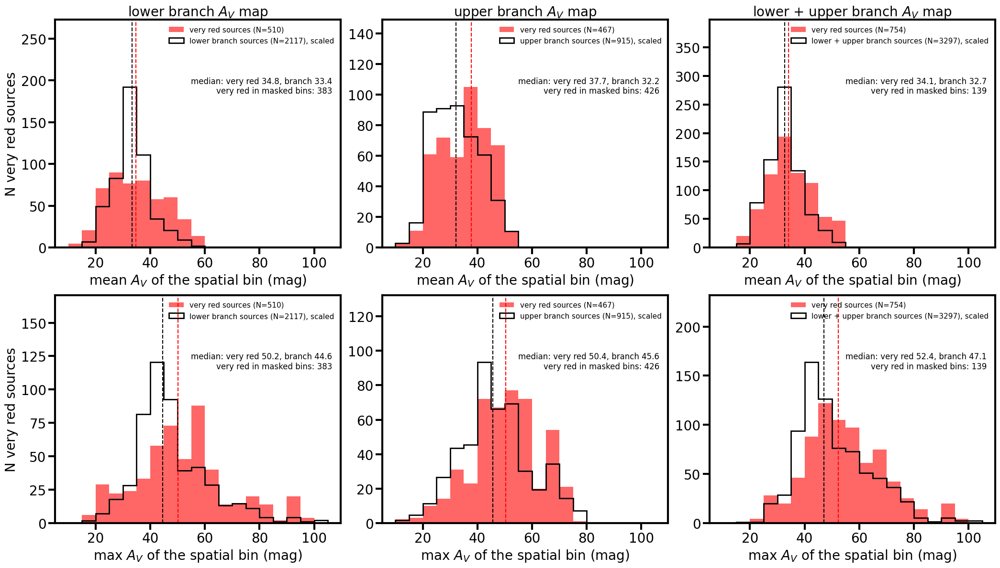

In [13]:
# --- 5b: histogram of bin A_V (mean / max) counted by the very red sources in each bin ---
hist_av_bins = np.arange(10, 106, 5)

fig, axes = plt.subplots(2, len(cases), figsize=(7 * len(cases), 12))
for row, stat in enumerate(['mean', 'max']):
    for col, (label, tag, m, color) in enumerate(cases):
        ax = axes[row, col]
        xb = bin_av_at_src[stat][tag]
        vr = xb[veryred_mask & np.isfinite(xb)]
        br = xb[m & np.isfinite(xb)]
        n_vr_masked = (veryred_mask & ~np.isfinite(xb)).sum()

        ax.hist(vr, bins=hist_av_bins, color='r', alpha=0.6, label=f'very red sources (N={vr.size})')
        # branch sources of this map, rescaled to the very red total for shape comparison
        ax.hist(br, bins=hist_av_bins, weights=np.full(br.size, vr.size / br.size), histtype='step',
                color='k', lw=2, label=f'{label} sources (N={br.size}), scaled')
        ax.axvline(np.median(vr), color='r', ls='--', lw=1.5)
        ax.axvline(np.median(br), color='k', ls='--', lw=1.5)
        ax.text(0.97, 0.75, f'median: very red {np.median(vr):.1f}, branch {np.median(br):.1f}\n'
                f'very red in masked bins: {n_vr_masked}',
                transform=ax.transAxes, ha='right', va='top', fontsize=12)
        print(f'{stat:4s} {label:22s} very red: N = {vr.size:4d} (in masked bins: {n_vr_masked:4d}), '
              f'median bin A_V = {np.median(vr):.1f}; branch sources median bin A_V = {np.median(br):.1f}')

        ax.set_xlabel(f'{stat} $A_V$ of the spatial bin (mag)')
        if col == 0:
            ax.set_ylabel('N very red sources')
        if row == 0:
            ax.set_title(f'{label} $A_V$ map')
        ax.set_ylim(0, ax.get_ylim()[1] * 1.35)  # headroom for the legend and text
        ax.legend(fontsize=11, frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig('bin_av_hist_veryred_branches_cfit003.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Consistency of $A_V$ between the lower and upper branches

If the two branches sample the same cloud along each line of sight, their $A_V$ should agree in the same place. Two tests:

**6a. Bin by bin.** For spatial bins valid in both the lower- and upper-branch maps ($N_{\rm bin} \geq$ `min_samples` in each), compare the mean and the max $A_V$ (Sections 1 and 3). Points are colored by $\log_{10}(N_{\rm lower}/N_{\rm upper})$ in the bin. The max of a sample grows with the number of sources drawn, and the lower branch has about twice as many sources as the upper branch. The max comparison is therefore biased toward higher lower-branch values in bins where $N_{\rm lower} > N_{\rm upper}$; the mean has no such bias. The printed statistics are the median and the robust scatter ($1.4826\times$MAD) of $\Delta A_V = A_V^{\rm upper} - A_V^{\rm lower}$, and the Spearman $\rho$.

**6b. Source by source.** Each upper-branch source is compared with the median $A_V$ of its `k_nn` nearest lower-branch neighbors on the sky. This test does not depend on the bin grid. The scatter expected from the lower-branch neighbors alone is shown for reference: each lower-branch source compared with its own `k_nn` nearest other lower-branch neighbors. If the upper branch sits in the same cloud as the lower branch, the two $\Delta A_V$ distributions should look alike.

bins valid in both maps: 122 (lower only: 123, upper only: 36)
mean: median dA_V (upper - lower) = -0.66, robust sigma = 9.66, Spearman rho = 0.336 (p = 1.5e-04)
max : median dA_V (upper - lower) = -5.52, robust sigma = 18.36, Spearman rho = 0.245 (p = 6.4e-03)


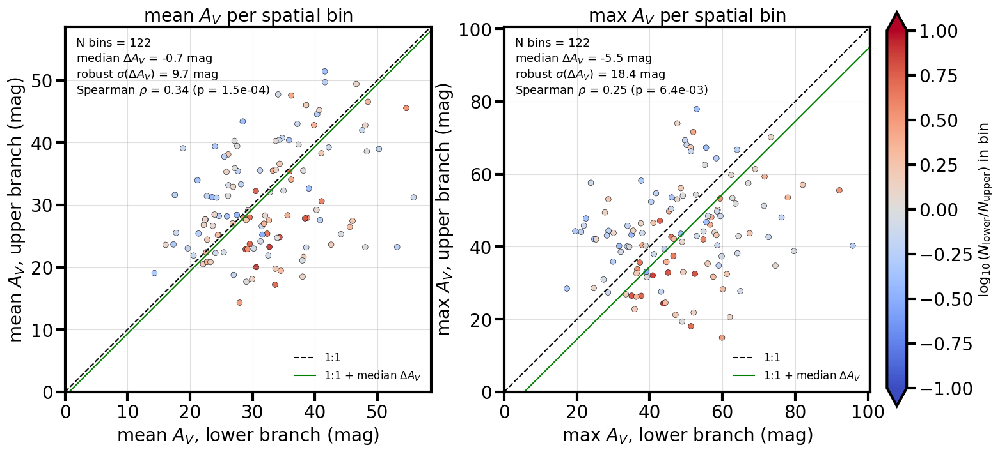

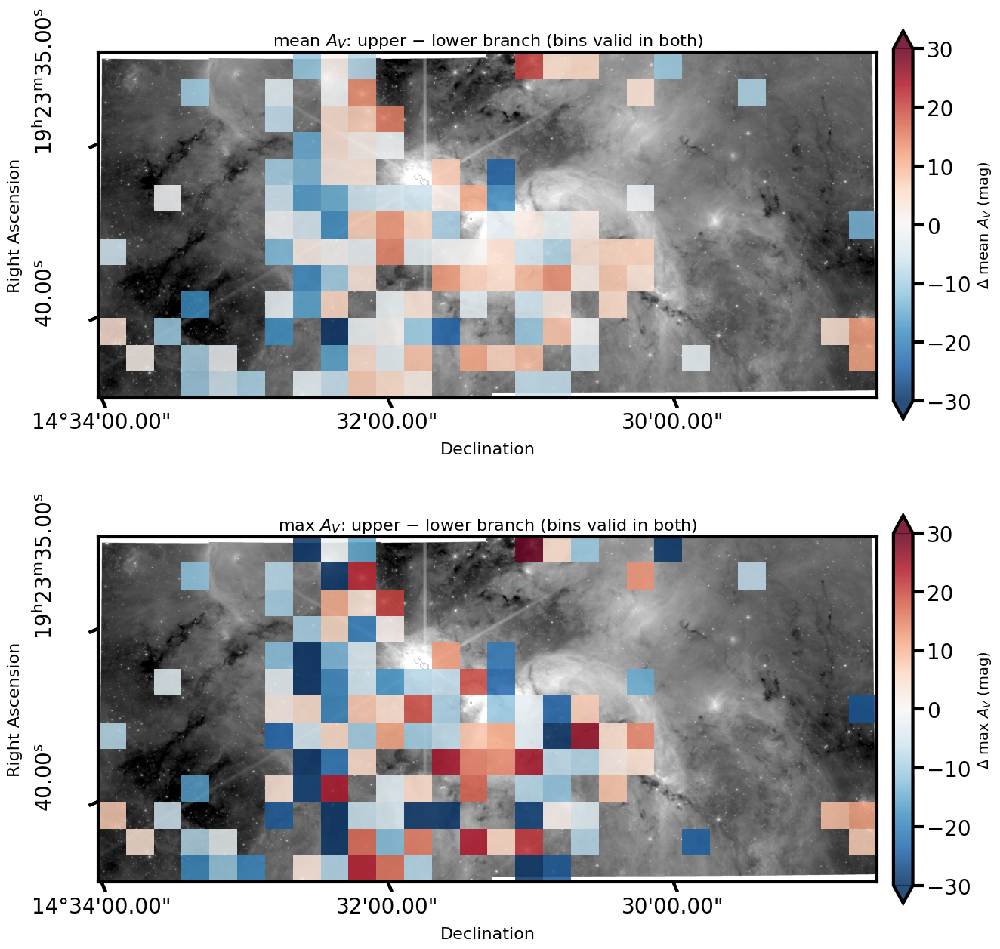

In [14]:
# --- 6a: bin-by-bin lower vs upper A_V (mean and max) ---
bin_counts = {}
for label, tag, m, color in cases:
    bin_counts[tag], _, _, _ = binned_statistic_2d(pixcoord_ref[0][m], pixcoord_ref[1][m], av_estimate[m],
                                                   statistic='count', bins=[xedges, yedges])
both_valid = np.isfinite(av_mean_maps['lower']) & np.isfinite(av_mean_maps['upper'])
log_n_ratio = np.log10(bin_counts['lower'][both_valid] / bin_counts['upper'][both_valid])
print(f'bins valid in both maps: {both_valid.sum()} '
      f'(lower only: {(np.isfinite(av_mean_maps["lower"]) & ~both_valid).sum()}, '
      f'upper only: {(np.isfinite(av_mean_maps["upper"]) & ~both_valid).sum()})')


def robust_std(a):
    return 1.4826 * np.median(np.abs(a - np.median(a)))


fig, axes = plt.subplots(1, 2, figsize=(17, 8))
for ax, (stat, maps) in zip(axes, [('mean', av_mean_maps), ('max', av_max_maps)]):
    av_lo, av_up = maps['lower'][both_valid], maps['upper'][both_valid]
    dav = av_up - av_lo
    rho, p = spearmanr(av_lo, av_up)
    im = ax.scatter(av_lo, av_up, c=log_n_ratio, cmap='coolwarm', vmin=-1, vmax=1, s=40,
                    edgecolors='k', linewidths=0.4)
    lim = [0, np.nanmax([av_lo.max(), av_up.max()]) * 1.05]
    ax.plot(lim, lim, 'k--', lw=1.5, label='1:1')
    ax.plot(lim, np.array(lim) + np.median(dav), 'g-', lw=1.5, label=rf'1:1 + median $\Delta A_V$')
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.text(0.03, 0.97, f'N bins = {both_valid.sum()}\n'
            rf'median $\Delta A_V$ = {np.median(dav):+.1f} mag' + '\n'
            rf'robust $\sigma(\Delta A_V)$ = {robust_std(dav):.1f} mag' + '\n'
            rf'Spearman $\rho$ = {rho:.2f} (p = {p:.1e})',
            transform=ax.transAxes, ha='left', va='top', fontsize=13)
    ax.set_xlabel(f'{stat} $A_V$, lower branch (mag)')
    ax.set_ylabel(f'{stat} $A_V$, upper branch (mag)')
    ax.set_title(f'{stat} $A_V$ per spatial bin')
    ax.legend(fontsize=12, frameon=False, loc='lower right')
    ax.grid(alpha=0.4)
    print(f'{stat:4s}: median dA_V (upper - lower) = {np.median(dav):+.2f}, robust sigma = {robust_std(dav):.2f}, '
          f'Spearman rho = {rho:.3f} (p = {p:.1e})')
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, extend='both')
cbar.set_label(r'$\log_{10}(N_{\rm lower}/N_{\rm upper})$ in bin', fontsize=16)
plt.savefig('av_lower_vs_upper_per_bin_cfit003.png', bbox_inches='tight', dpi=150)
plt.show()

# spatial map of Delta A_V (upper - lower), mean and max
dav_vlim = 30
fig, axes = plt.subplots(2, 1, figsize=(14, 15), subplot_kw={'projection': wcs_f480m})
for axi, (stat, maps) in zip(axes, [('mean', av_mean_maps), ('max', av_max_maps)]):
    axi.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
    im = axi.imshow((maps['upper'] - maps['lower']).T, origin='lower', cmap='RdBu_r',
                    vmin=-dav_vlim, vmax=dav_vlim, alpha=0.85,
                    extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()], interpolation='nearest')
    format_wcs_axes(axi)
    axi.set_xlabel('Declination', fontsize=16)
    axi.set_ylabel('Right Ascension', fontsize=16)
    axi.set_title(f'{stat} $A_V$: upper $-$ lower branch (bins valid in both)', fontsize=16)
    cbar = fig.colorbar(im, ax=axi, fraction=0.03, pad=0.02, extend='both')
    cbar.set_label(rf'$\Delta$ {stat} $A_V$ (mag)', fontsize=14)
fig.subplots_adjust(hspace=0.25)
plt.savefig('av_upper_minus_lower_map_cfit003.png', bbox_inches='tight', dpi=150)
plt.show()

median distance to the 10th lower-branch neighbor: upper 9.3", lower 6.8"
upper - lower-neighbor median          N =  1106  median dA_V = +0.89  robust sigma = 11.38
lower - lower-neighbor median (ref.)   N =  2260  median dA_V = +0.21  robust sigma = 6.45


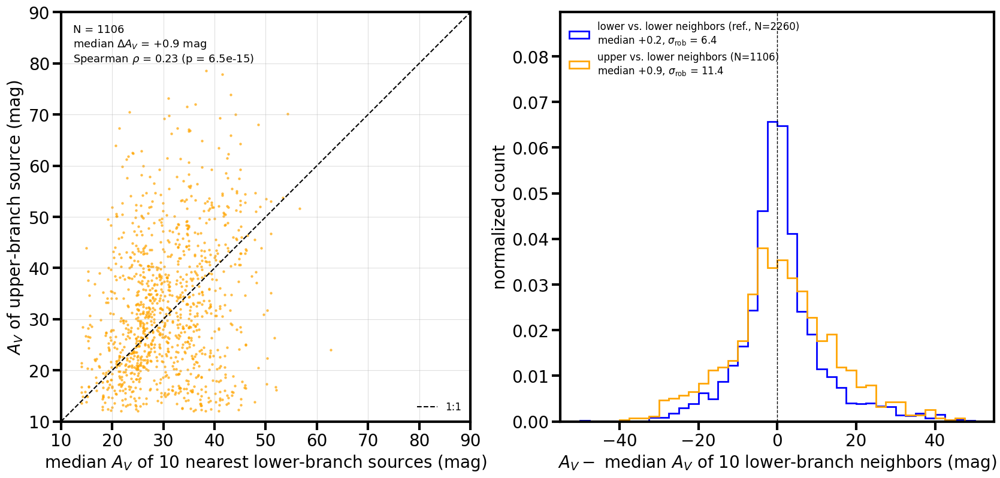

In [15]:
# --- 6b: each upper-branch source vs the median A_V of its k nearest lower-branch neighbors ---
from scipy.spatial import cKDTree

k_nn = 10
xy_lower = np.column_stack([pixcoord_ref[0][lower_mask], pixcoord_ref[1][lower_mask]])
xy_upper = np.column_stack([pixcoord_ref[0][upper_mask], pixcoord_ref[1][upper_mask]])
av_lower_src, av_upper_src = av_estimate[lower_mask], av_estimate[upper_mask]
tree_lower = cKDTree(xy_lower)

# upper-branch sources vs their k nearest lower-branch sources
dist_u, idx_u = tree_lower.query(xy_upper, k=k_nn)
av_nn_upper = np.median(av_lower_src[idx_u], axis=1)
dav_upper = av_upper_src - av_nn_upper

# reference: lower-branch sources vs their k nearest *other* lower-branch sources
dist_l, idx_l = tree_lower.query(xy_lower, k=k_nn + 1)
av_nn_lower = np.median(av_lower_src[idx_l[:, 1:]], axis=1)
dav_lower = av_lower_src - av_nn_lower

pix_scale_arcsec = wcs_f480m.proj_plane_pixel_scales()[0].to_value(u.arcsec)
print(f'median distance to the {k_nn}th lower-branch neighbor: upper {np.median(dist_u[:, -1]) * pix_scale_arcsec:.1f}", '
      f'lower {np.median(dist_l[:, -1]) * pix_scale_arcsec:.1f}"')
for name, d in [('upper - lower-neighbor median', dav_upper), ('lower - lower-neighbor median (ref.)', dav_lower)]:
    print(f'{name:38s} N = {d.size:5d}  median dA_V = {np.median(d):+.2f}  robust sigma = {robust_std(d):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
ax = axes[0]
ax.scatter(av_nn_upper, av_upper_src, s=5, c='orange', alpha=0.6, rasterized=True)
rho, p = spearmanr(av_nn_upper, av_upper_src)
lim = [10, 90]
ax.plot(lim, lim, 'k--', lw=1.5, label='1:1')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.set_xlabel(f'median $A_V$ of {k_nn} nearest lower-branch sources (mag)')
ax.set_ylabel(r'$A_V$ of upper-branch source (mag)')
ax.text(0.03, 0.97, f'N = {dav_upper.size}\n'
        rf'median $\Delta A_V$ = {np.median(dav_upper):+.1f} mag' + '\n'
        rf'Spearman $\rho$ = {rho:.2f} (p = {p:.1e})',
        transform=ax.transAxes, ha='left', va='top', fontsize=13)
ax.legend(fontsize=12, frameon=False, loc='lower right')
ax.grid(alpha=0.4)

ax = axes[1]
dbins = np.arange(-50, 52, 2.5)
ax.hist(dav_lower, bins=dbins, density=True, histtype='step', color='blue', lw=2,
        label=f'lower vs. lower neighbors (ref., N={dav_lower.size})\n'
              rf'median {np.median(dav_lower):+.1f}, $\sigma_{{\rm rob}}$ = {robust_std(dav_lower):.1f}')
ax.hist(dav_upper, bins=dbins, density=True, histtype='step', color='orange', lw=2,
        label=f'upper vs. lower neighbors (N={dav_upper.size})\n'
              rf'median {np.median(dav_upper):+.1f}, $\sigma_{{\rm rob}}$ = {robust_std(dav_upper):.1f}')
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel(rf'$A_V - $ median $A_V$ of {k_nn} lower-branch neighbors (mag)')
ax.set_ylabel('normalized count')
ax.set_ylim(0, ax.get_ylim()[1] * 1.3)  # headroom for the legend
ax.legend(fontsize=12, frameon=False, loc='upper left')
plt.tight_layout()
plt.savefig('av_upper_vs_lower_neighbors_cfit003.png', bbox_inches='tight', dpi=150)
plt.show()